# **Credit Risk Scoring**

# 1. Introduction

The objective of this project is to develop a machine learning model to estimate the **Probability of Default (PD)** of credit card clients and transform this probability into an interpretable **credit score**.

Two models will be compared:

- Logistic Regression, as a traditional and interpretable credit risk model;
- XGBoost, as a more flexible machine learning approach for tabular data.


# 2. Data Understanding

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

In [7]:
credit_data = fetch_ucirepo(id=350)

X = credit_data.data.features.copy()
y = credit_data.data.targets.copy()

df_og = pd.concat([X, y], axis=1)

In [8]:
df= df_og.copy()
df.shape

(30000, 24)

In [ ]:
column_names = {
    "X1": "credit_limit",
    "X2": "sex",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",
    
    "X6": "payment_status_sep",
    "X7": "payment_status_aug",
    "X8": "payment_status_jul",
    "X9": "payment_status_jun",
    "X10": "payment_status_may",
    "X11": "payment_status_apr",
    
    "X12": "bill_amount_sep",
    "X13": "bill_amount_aug",
    "X14": "bill_amount_jul",
    "X15": "bill_amount_jun",
    "X16": "bill_amount_may",
    "X17": "bill_amount_apr",
    
    "X18": "payment_amount_sep",
    "X19": "payment_amount_aug",
    "X20": "payment_amount_jul",
    "X21": "payment_amount_jun",
    "X22": "payment_amount_may",
    "X23": "payment_amount_apr",
    
    "Y": "default"
}

In [ ]:
df = df.rename(columns=column_names)

df.head()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 30,000
Columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   sex                 30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   payment_status_sep  30000 non-null  int64
 6   payment_status_aug  30000 non-null  int64
 7   payment_status_jul  30000 non-null  int64
 8   payment_status_jun  30000 non-null  int64
 9   payment_status_may  30000 non-null  int64
 10  payment_status_apr  30000 non-null  int64
 11  bill_amount_sep     30000 non-null  int64
 12  bill_amount_aug     30000 non-null  int64
 13  bill_amount_jul     30000 non-null  int64
 14  bill_amount_jun     30000 non-null  int64
 15  bill_amount_may     30000 non-null  int64
 16  bill_amount_apr

In [12]:
df.isna().sum().value_counts()

0    24
Name: count, dtype: int64

Duplicates

In [13]:
df.duplicated().sum()

35

In [16]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6)

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
12430,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7170,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17032,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


It is not clear if the index stands for an ID. I am inclined to agree that it does not, as it is sorted from 1 to 30000 just like a regular index. Let's proceed by checking if these entries are exact duplicates, which means that the target itself would assume the same value as the 'original entries' on the duplicates. If this happens to occur, I believe we have substantial evidence to remove the duplicates.

In [19]:
df_og.duplicated().sum()

35

In [20]:
df.drop_duplicates(inplace=True)

35 exact duplicate observations were identified and removed. Since the dataset does not provide a meaningful customer identifier to confirm that these records correspond to distinct clients, duplicates were treated as repeated observations.

In [22]:
for col in ["sex", "education", "marital_status"]:
    print(df[col].value_counts().sort_index())

sex
1    11874
2    18091
Name: count, dtype: int64
education
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64
marital_status
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


In [23]:
df["default"].value_counts()

default
0    23335
1     6630
Name: count, dtype: int64

In [27]:
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

In [28]:
# Group undocumented categories into "Others"
df["education"] = df["education"].replace({
    0: 4,
    5: 4,
    6: 4
})

df["marital_status"] = df["marital_status"].replace({
    0: 3
})

In [30]:
for col in ["sex", "education", "marital_status"]:
    print(df[col].value_counts().sort_index())

sex
1    11874
2    18091
Name: count, dtype: int64
education
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64
marital_status
1    13643
2    15945
3      377
Name: count, dtype: int64


In [31]:
sex_labels = {
    1: "Male",
    2: "Female"
}

education_labels = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other"
}

marital_labels = {
    1: "Married",
    2: "Single",
    3: "Other"
}

In [32]:
payment_status_cols = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

for col in payment_status_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


payment_status_sep
payment_status_sep
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

payment_status_aug
payment_status_aug
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

payment_status_jul
payment_status_jul
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

payment_status_jun
payment_status_jun
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

payment_status_may
payment_status_may
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

payment_status_apr
payment

Repayment status:

- -2: no consumption

- -1: paid duly

- 0: revolving credit

- 1–8:  number of months of payment delay

# 3. Exploratory Data Analysis

In [40]:
df.head()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3.1 Target Distribution

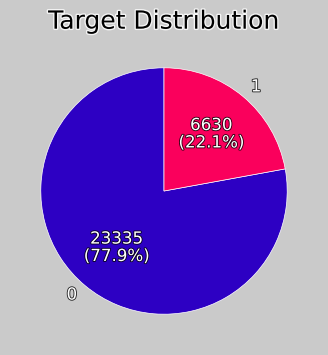

In [84]:
import matplotlib.patheffects as path_effects 

target_counts = df['default'].value_counts()

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}\n({pct:.1f}%)' 
    return my_autopct

fig, ax = plt.subplots(figsize=(5, 5))

ax = target_counts.plot.pie(
    autopct=make_autopct(target_counts),
    startangle=90, 
    figsize=(4, 4),
    colors=["#2D00C3", "#FA005C"],
    textprops={'fontsize': 12, 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}, 
)

for text in ax.texts:
    text.set_path_effects([
        path_effects.withStroke(linewidth=1.3, foreground='black', alpha=0.8)
    ])

fig.patch.set_facecolor("#CACACA") 
ax.set_facecolor('#CACACA')

title = plt.title('Target Distribution', color='black', fontsize=18)
title.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white', alpha=0.8)])
plt.ylabel('')
plt.show()

In [82]:
df['default'].value_counts(normalize=True).round(3)

default
0    0.779
1    0.221
Name: proportion, dtype: float64

Approximately 22% of clients defaulted on their credit card payments. Although the target is moderately imbalanced, the minority class is sufficiently represented to train and evaluate classification models without applying resampling techniques initially.

## 3.2 - Default Rate by Most Recent Repayment Status

In [85]:
payment_default_rate = (
    df.groupby("payment_status_sep")["default"]
      .agg(["count", "mean"])
      .reset_index()
)

# payment_default_rate

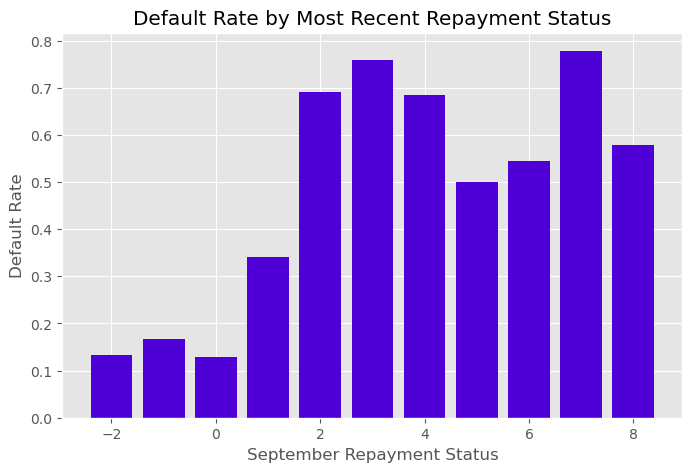

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    payment_default_rate["payment_status_sep"],
    payment_default_rate["mean"],
    color="#4f00d6"
)

ax.set_xlabel("September Repayment Status")
ax.set_ylabel("Default Rate")
ax.set_title("Default Rate by Most Recent Repayment Status")

plt.show()

## 3.3 Default Rate Across Six Months

In [86]:
payment_status_cols = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]

payment_rates = []

for col, month in zip(payment_status_cols, months):
    temp = (
        df.groupby(col)["default"]
          .mean()
          .reset_index()
    )
    
    temp.columns = ["payment_status", "default_rate"]
    temp["month"] = month
    
    payment_rates.append(temp)

payment_rates = pd.concat(payment_rates, ignore_index=True)

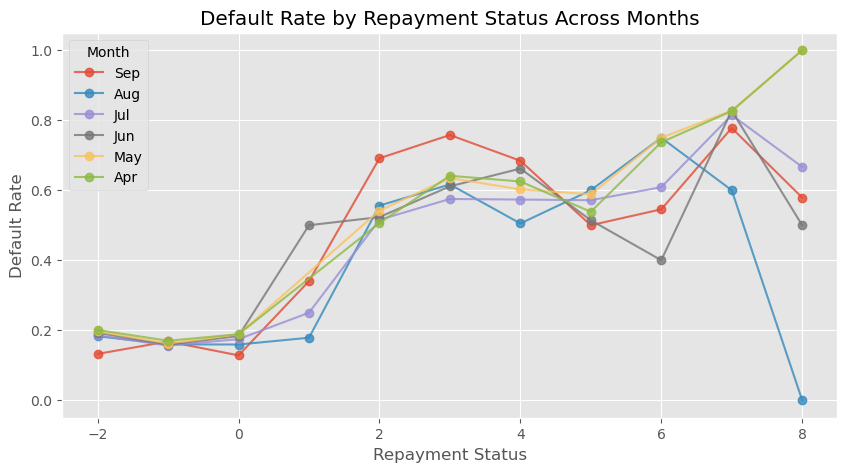

In [121]:
fig, ax = plt.subplots(figsize=(10, 5))

for month in months:
    temp = payment_rates[payment_rates["month"] == month]
    
    ax.plot(
        temp["payment_status"],
        temp["default_rate"],
        marker="o",
        label=month,
        alpha=0.8,
    )

ax.set_title("Default Rate by Repayment Status Across Months")
ax.set_xlabel("Repayment Status")
ax.set_ylabel("Default Rate")
ax.legend(title="Month")

plt.show()

## 3.4 Credit Limit vs Default

In [99]:
df.groupby("default")["credit_limit"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,23335.0,178084.508249,131665.894718,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6630.0,129984.567119,115258.618215,10000.0,50000.0,90000.0,200000.0,740000.0


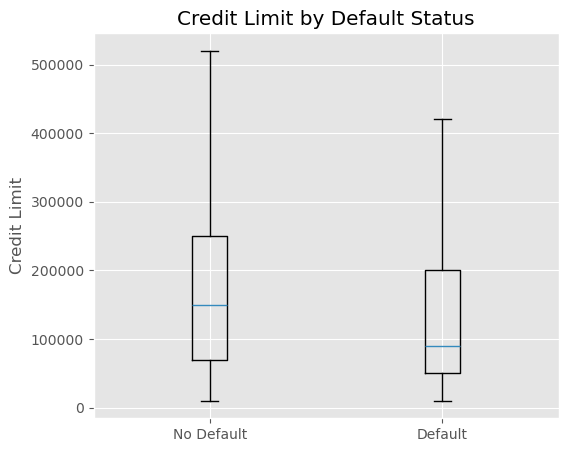

In [102]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [
        df.loc[df["default"] == 0, "credit_limit"],
        df.loc[df["default"] == 1, "credit_limit"]
    ],
    labels=["No Default", "Default"],
    showfliers=False
)

ax.set_title("Credit Limit by Default Status")
ax.set_ylabel("Credit Limit")

plt.show()

Clients who defaulted tend to have lower credit limits. However, this relationship should be interpreted as an association rather than a causal effect, since credit limits are themselves influenced by the financial profile of each client.

## 3.5 Age vs Default

In [104]:
age_bins = [20, 30, 40, 50, 60, 70, 100]
age_labels = [
    "20–29",
    "30–39",
    "40–49",
    "50–59",
    "60–69",
    "70+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [106]:
age_default_rate = (
    df.groupby("age_group", observed=False)["default"]
      .agg(["count", "mean"])
      .reset_index()
)

# age_default_rate

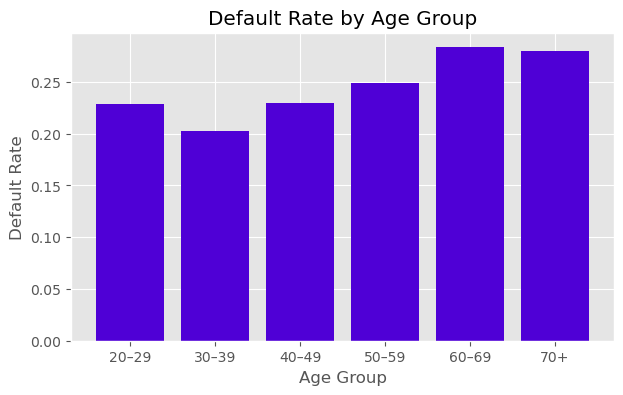

In [117]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    age_default_rate["age_group"].astype(str),
    age_default_rate["mean"],
    color="#4f00d6"
)

ax.set_title("Default Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Default Rate")

plt.show()

In [122]:
df = df.drop(columns="age_group")

## 3.6 Payment Ratio

In [123]:
positive_bill = df["bill_amount_sep"] > 0

df.loc[positive_bill].assign(
    payment_ratio=lambda x:
        x["payment_amount_sep"] / x["bill_amount_sep"]
).groupby("default")["payment_ratio"].median()

default
0    0.065843
1    0.050262
Name: payment_ratio, dtype: float64

In [124]:
eda_payment = df.loc[df["bill_amount_sep"] > 0].copy()

eda_payment["payment_ratio"] = (
    eda_payment["payment_amount_sep"] /
    eda_payment["bill_amount_sep"]
)

eda_payment["payment_ratio"] = eda_payment["payment_ratio"].clip(0, 2)

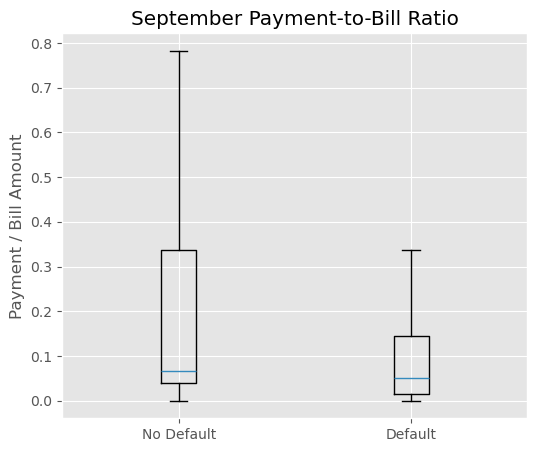

In [126]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [
        eda_payment.loc[
            eda_payment["default"] == 0,
            "payment_ratio"
        ],
        eda_payment.loc[
            eda_payment["default"] == 1,
            "payment_ratio"
        ]
    ],
    labels=["No Default", "Default"],
    showfliers=False
)

ax.set_title("September Payment-to-Bill Ratio")
ax.set_ylabel("Payment / Bill Amount")

plt.show()

# 4. Data Processing

# 5. Logistic Regression

# 6. XGBoost

# 7. Model Comparison

# 8. Credit Score

# 9. Model Explainability

# 10. Conclusion